# Exploration of the Global Land Cover dataset

In [1]:
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import geopandas as gpd
from shapely.geometry import box
from pathlib import Path

In [2]:
GCLC_DIR = "../datasets/GCLC"

## Visualize data

### Plot US map

In [15]:
def plot_gclc_us_majority(gclc_dir, us_bounds=(-125, 24, -66.5, 49)):
    files = sorted([f for f in os.listdir(gclc_dir) if f.endswith('.tif')])
    class_names = [os.path.splitext(f)[0] for f in files]
    if not files:
        print("No .tif files found in directory.")
        return

    with rasterio.open(os.path.join(gclc_dir, files[0])) as ref:
        window = from_bounds(*us_bounds, transform=ref.transform)

    data_stack = []
    fill_value = 255
    for fname in files:
        path = os.path.join(gclc_dir, fname)
        with rasterio.open(path) as ds:
            data = ds.read(1, window=window, masked=True)
            data_stack.append(data.filled(fill_value))

    data_stack = np.stack(data_stack, axis=0).astype(float)
    mask = np.all(data_stack == fill_value, axis=0)
    data_stack[data_stack == fill_value] = -np.inf

    majority_idx = np.argmax(data_stack, axis=0)
    majority_idx[mask] = -1

    # Plot
    plt.figure(figsize=(12, 7))
    cmap = plt.get_cmap('tab20', len(class_names))
    im = plt.imshow(majority_idx, origin="upper", extent=us_bounds, cmap=cmap, vmin=0, vmax=len(class_names)-1)
    # plt.colorbar(im, label="GCLC Majority Class Index")
    plt.title("US Majority Land Cover (GCLC)")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    # Add legend for classes
    handles = [mpatches.Patch(color=cmap(i), label=class_names[i]) for i in range(len(class_names))]
    plt.legend(handles=handles, bbox_to_anchor=(0.5, -0.15), loc='upper center', title="Land Cover Class")

    # plt.tight_layout()
    plt.show()

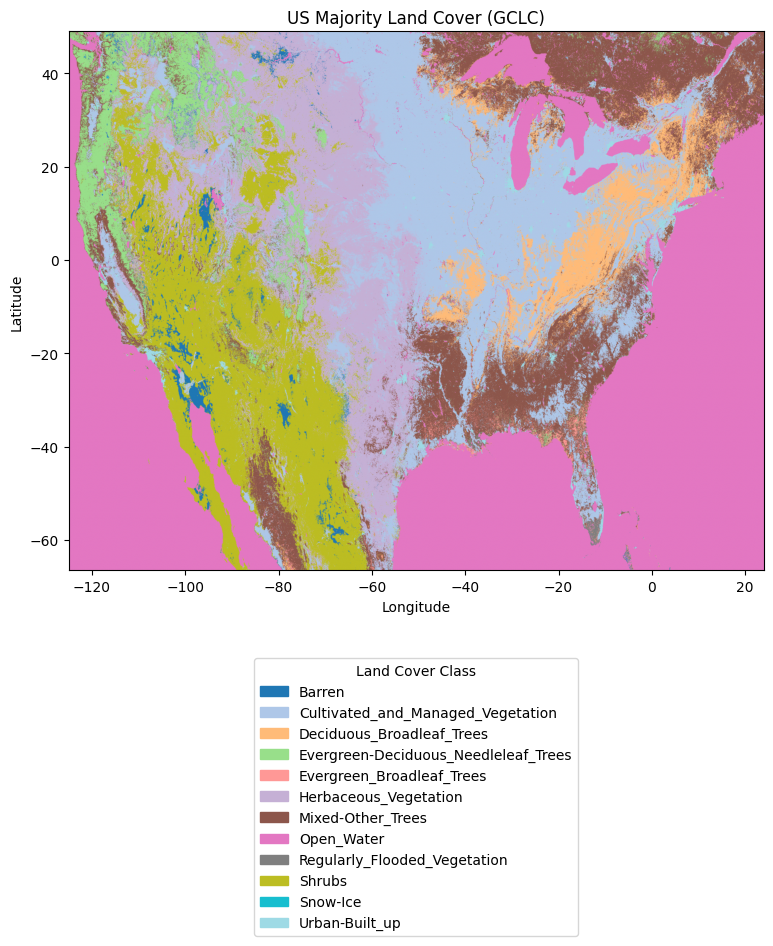

In [16]:
plot_gclc_us_majority(gclc_dir=GCLC_DIR, us_bounds=(-125, 24, -66.5, 49))

### Plot a patch

#### single class

In [ ]:
def plot_gclc_patch(lat, lon, size_km, gclc_dir, landcover_class=None):
    """
    Plot a patch of size_km x size_km km from the GCLC dataset, optionally overlayed on a map.
    If landcover_class is None, plots the first available class.
    """
    half_h = size_km / 111.32
    half_w = size_km / (111.32 * np.cos(np.deg2rad(lat)))
    bounds = (
        lon - half_w,
        lat - half_h,
        lon + half_w,
        lat + half_h
    )

    # Pick a landcover class if not specified
    files = [f for f in os.listdir(gclc_dir) if f.endswith('.tif')]
    if not files:
        print("No .tif files found in directory.")
        return
    if landcover_class is None:
        fname = files[0]
    else:
        fname = f"{landcover_class}.tif"
        if fname not in files:
            print(f"{fname} not found in directory.")
            return

    path = os.path.join(gclc_dir, fname)
    with rasterio.open(path) as ds:
        window = from_bounds(*bounds, ds.transform)
        data = ds.read(1, window=window, masked=True)
        # Get extent in lon/lat for plotting
        left, bottom = bounds[0], bounds[1]
        right, top = bounds[2], bounds[3]
        extent = [left, right, bottom, top]

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(data, extent=extent, origin='upper', cmap='viridis', alpha=0.7)
    plt.colorbar(im, ax=ax, label='Landcover %')
    ax.set_title(f"{fname} ({size_km}x{size_km} km patch)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # Overlay with a basemap
    try:
        # contextily expects Web Mercator, so convert extent and set CRS
        gdf = gpd.GeoDataFrame({'geometry': [box(*extent)]}, crs="EPSG:4326")
        gdf = gdf.to_crs(epsg=3857)
        ax.set_xlim(*gdf.total_bounds[[0,2]])
        ax.set_ylim(*gdf.total_bounds[[1,3]])
        ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.Stamen.TerrainBackground)
    except Exception as e:
        print("Could not add basemap:", e)

    plt.show()

In [ ]:
plot_gclc_patch(
    lat=39.7392, lon=-104.9903,  # Denver
    size_km=10,
    gclc_dir=GCLC_DIR,
    landcover_class='forest'  # or specify a class, e.g. 'forest'
)

forest.tif not found in directory.


#### all classes

In [25]:
def plot_gclc_majority_patch(lat, lon, size_km, gclc_dir, class_colors=None):
    """
    Plot a patch showing the majority land cover class at each pixel.
    """

    # Get all .tif files and class names
    files = sorted([f for f in os.listdir(gclc_dir) if f.endswith('.tif')])
    class_names = [os.path.splitext(f)[0] for f in files]
    if not files:
        print("No .tif files found in directory.")
        return

    # Calculate bounds
    half_h = size_km / 111.32
    half_w = size_km / (111.32 * np.cos(np.deg2rad(lat)))
    bounds = (
        lon - half_w,
        lat - half_h,
        lon + half_w,
        lat + half_h
    )

    # Read all class data into a stack
    data_stack = []
    fill_value = 255  # valid for uint8, and likely unused as a percentage
    for fname in files:
        path = os.path.join(gclc_dir, fname)
        with rasterio.open(path) as ds:
            window = from_bounds(*bounds, ds.transform)
            data = ds.read(1, window=window, masked=True)
            data_stack.append(data.filled(fill_value))  # fill masked with 255

    data_stack = np.stack(data_stack, axis=0).astype(float)  # ensure float type
    # Mask out pixels where all classes are masked
    mask = np.all(data_stack == fill_value, axis=0)
    data_stack[data_stack == fill_value] = -np.inf  # so they never win

    # Find majority class index at each pixel
    majority_idx = np.argmax(data_stack, axis=0)
    majority_idx[mask] = -1  # set masked pixels to -1

    # Color map for classes
    if class_colors is None:
        cmap = plt.get_cmap('tab20', len(class_names))
        class_colors = [cmap(i) for i in range(len(class_names))]
    else:
        cmap = None

    # Plot
    left, bottom = bounds[0], bounds[1]
    right, top = bounds[2], bounds[3]
    extent = [left, right, bottom, top]

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(majority_idx, extent=extent, origin='upper', cmap=cmap, vmin=0, vmax=len(class_names)-1)
    ax.set_title(f"Majority Land Cover Class ({size_km}x{size_km} km patch)")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")

    # Legend
    handles = [mpatches.Patch(color=class_colors[i], label=class_names[i]) for i in range(len(class_names))]
    ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Overlay with a basemap
    try:
        gdf = gpd.GeoDataFrame({'geometry': [box(*extent)]}, crs="EPSG:4326")
        gdf = gdf.to_crs(epsg=3857)
        ax.set_xlim(*gdf.total_bounds[[0,2]])
        ax.set_ylim(*gdf.total_bounds[[1,3]])
        ctx.add_basemap(ax, crs=gdf.crs.to_string(), source=ctx.providers.Stamen.TerrainBackground)
    except Exception as e:
        print("Could not add basemap:", e)

    plt.tight_layout()
    plt.show()

Could not add basemap: Axis limits cannot be NaN or Inf


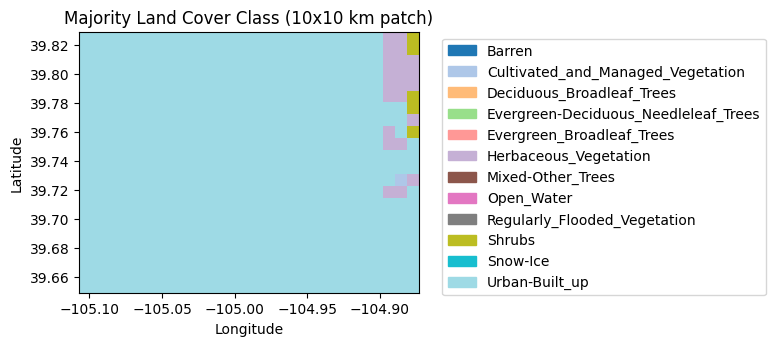

In [26]:
plot_gclc_majority_patch(
    lat=39.7392, lon=-104.9903,  # Denver
    size_km=10,
    gclc_dir=GCLC_DIR
)

## Average coverage per point

In [3]:
def gclc_features(
    lat,
    lon,
    radius_km,
    gclc_dir,
    agg="mean"
):
    """
    Compute land cover percentages from Global 1km Consensus Land Cover.

    Parameters
    ----------
    lat, lon : float
        Latitude and longitude in degrees.
    radius_km : float
        Radius of square window in kilometers.
    gclc_dir : str
        Directory containing GCLC .tif files.
    agg : str
        Aggregation method: 'mean', 'sum', 'median'.

    Returns
    -------
    dict
        {landcover_class: aggregated_percentage}
    """

    # --- km -> degrees ---
    half_h = radius_km / 111.32
    half_w = radius_km / (111.32 * np.cos(np.deg2rad(lat)))

    bounds = (
        lon - half_w,
        lat - half_h,
        lon + half_w,
        lat + half_h
    )

    results = {}

    for fname in os.listdir(gclc_dir):
        if not fname.endswith(".tif"):
            continue

        lc_name = os.path.splitext(fname)[0]

        with rasterio.open(os.path.join(gclc_dir, fname)) as ds:
            window = from_bounds(*bounds, ds.transform)
            data = ds.read(1, window=window, masked=True)

            if data.mask.all():
                value = np.nan
            else:
                if agg == "mean":
                    value = data.mean()
                elif agg == "sum":
                    value = data.sum()
                elif agg == "median":
                    value = np.median(data.compressed())
                else:
                    raise ValueError(f"Unknown agg: {agg}")

        results[lc_name] = float(value)

    return results


In [10]:
def process_features(features):
    total_percentage = sum(features.values())
    if total_percentage == 0:
        print("Total percentage is zero, cannot normalize.")
        return features
    
    feats = {
        "BARREN": features.get("Barren", 0.0),
        "CULTIVATED": features.get("Cultivated_and_Managed_Vegetation", 0.0),
        "VEGETATION": features.get("Shrubs", 0.0) + 
            features.get("Herbaceous_Vegetation", 0.0) +
            features.get("Regularly_Flooded_Vegetation", 0.0),
        "FOREST": features.get("Deciduous_Broadleaf_Trees", 0.0) +
            features.get("Evergreen-Deciduous_Needleleaf_Trees", 0.0) +
            features.get("Evergreen_Broadleaf_Trees", 0.0) + 
            features.get("Mixed-Other_Trees", 0.0),
        "WATER": features.get("Open_Water", 0.0),
        "SNOW_ICE": features.get("Snow-Ice", 0.0),
        "URBAN": features.get("Urban-Built_up", 0.0)
    }
    # round to 1 decimal
    feats = {k: round(v, 1) for k, v in feats.items()}
    
    return feats

In [11]:
features = gclc_features(
    lat=39.7392,
    lon=-104.9903,   # Denver
    radius_km=10,
    gclc_dir=GCLC_DIR,
    agg="mean"
)

print('raw', features)
print('processed', process_features(features))

raw {'Barren': 0.18344155844155843, 'Cultivated_and_Managed_Vegetation': 4.233766233766234, 'Deciduous_Broadleaf_Trees': 0.11363636363636363, 'Evergreen-Deciduous_Needleleaf_Trees': 11.198051948051948, 'Evergreen_Broadleaf_Trees': 1.2321428571428572, 'Herbaceous_Vegetation': 3.814935064935065, 'Mixed-Other_Trees': 6.2272727272727275, 'Open_Water': 0.387987012987013, 'Regularly_Flooded_Vegetation': 0.0, 'Shrubs': 4.753246753246753, 'Snow-Ice': 0.0, 'Urban-Built_up': 67.85551948051948}
processed {'BARREN': 0.2, 'CULTIVATED': 4.2, 'VEGETATION': 8.6, 'FOREST': 18.8, 'WATER': 0.4, 'SNOW_ICE': 0.0, 'URBAN': 67.9}


In [13]:
# sum all precentages to check if they sum to 100
total_percentage = sum(features.values())
print(f"Total percentage: {total_percentage:.2f}%")

Total percentage: 100.00%


## Add land coverage to the dataset

In [15]:
data_dir = Path('../datasets\\')

In [65]:
df = pd.read_csv(data_dir / 'disasters_new_feats/loc.csv')

In [68]:
df['BARREN'] = np.nan
df['CULTIVATED'] = np.nan
df['VEGETATION'] = np.nan
df['FOREST'] = np.nan
df['WATER'] = np.nan
df['SNOW_ICE'] = np.nan
df['URBAN'] = np.nan

df.head()

,BEGIN_LAT,BEGIN_LON,BARREN,CULTIVATED,VEGETATION,FOREST,WATER,SNOW_ICE,URBAN
0,34.94,-81.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,35.01,-80.93,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,35.64,-82.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,35.65,-84.18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,35.87,-83.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [69]:
i = 0
# add land coverage cols to df
for idx, row in df.iterrows():
    # skip if already computed
    if not pd.isna(df.at[idx, 'BARREN']) and not pd.isna(df.at[idx, 'CULTIVATED']) and not pd.isna(df.at[idx, 'VEGETATION']) \
            and not pd.isna(df.at[idx, 'FOREST']) and not pd.isna(df.at[idx, 'WATER']) and not pd.isna(df.at[idx, 'SNOW_ICE']) \
            and not pd.isna(df.at[idx, 'URBAN']):
        continue

    lat = row['BEGIN_LAT']
    lon = row['BEGIN_LON']
    feats = gclc_features(
        lat=lat,
        lon=lon,
        radius_km=10,
        gclc_dir=GCLC_DIR,
        agg="mean"
    )
    processed_feats = process_features(feats)
    for k, v in processed_feats.items():
        df.at[idx, k] = v

    # add also for any other col with the same coords and nan values, to avoid recomputing for the same location
    df.loc[((df['BEGIN_LAT'] == lat) & (df['BEGIN_LON'] == lon)) & (df['BARREN'].isna() & df['CULTIVATED'].isna() & df['VEGETATION'].isna() & 
        df['FOREST'].isna() & df['WATER'].isna() & df['SNOW_ICE'].isna() & df['URBAN'].isna()), \
           ['BARREN', 'CULTIVATED', 'VEGETATION', 'FOREST', 'WATER', 'SNOW_ICE', 'URBAN']] = \
        [processed_feats['BARREN'], processed_feats['CULTIVATED'], processed_feats['VEGETATION'], processed_feats['FOREST'], 
         processed_feats['WATER'], processed_feats['SNOW_ICE'], processed_feats['URBAN']]
    
    i += 1
    if i % 10000 == 0: 
        print(f"Processed {i} rows")

df.head()

Processed 10000 rows
Processed 20000 rows
Processed 30000 rows
Processed 40000 rows
Processed 50000 rows
Processed 60000 rows
Processed 70000 rows
Processed 80000 rows
Processed 90000 rows
Processed 100000 rows
Processed 110000 rows
Processed 120000 rows
Processed 130000 rows
Processed 140000 rows
Processed 150000 rows
Processed 160000 rows
Processed 170000 rows
Processed 180000 rows
Processed 190000 rows
Processed 200000 rows


,BEGIN_LAT,BEGIN_LON,BARREN,CULTIVATED,VEGETATION,FOREST,WATER,SNOW_ICE,URBAN
0,34.94,-81.03,0.0,15.7,3.9,70.8,1.2,0.0,8.5
1,35.01,-80.93,0.0,17.3,4.8,70.2,0.7,0.0,7.0
2,35.64,-82.14,0.0,5.6,0.6,93.6,0.1,0.0,0.1
3,35.65,-84.18,0.0,37.9,2.3,52.7,6.9,0.0,0.1
4,35.87,-83.77,0.0,40.5,1.6,56.7,0.6,0.0,0.5


In [70]:
df.to_csv(data_dir / 'disasters_new_feats/land_coverage.csv', index=False)

In [ ]:
df = pd.read_csv(data_dir / 'disasters_new_feats/land_coverage.csv')
df[['BARREN', 'CULTIVATED', 'VEGETATION', 'FOREST', 'WATER', 'SNOW_ICE', 'URBAN']] = df[['BARREN', 'CULTIVATED', 'VEGETATION', 'FOREST', 'WATER', 'SNOW_ICE', 'URBAN']] / 100.0
df[['BARREN', 'CULTIVATED', 'VEGETATION', 'FOREST', 'WATER', 'SNOW_ICE', 'URBAN']] = df[['BARREN', 'CULTIVATED', 'VEGETATION', 'FOREST', 'WATER', 'SNOW_ICE', 'URBAN']].round(4)
df.to_csv(data_dir / 'disasters_new_feats/land_coverage.csv', index=False)